In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
# %matplotlib notebook

In [2]:
import colorcet as cc

In [52]:
plt.style.use(['science'])
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['text.usetex'] = True

# Knapsack problem

In [4]:
def randChromeKnap(n):
    return np.random.choice([0, 1], size=n)

def fitnessKnap(c):
    weight = c @ weights
    value = c @ values
        
    if weight > maxWeight:
        return 0
    else:
        return value

def crossOverKnap(p1, p2):
    xo = np.random.randint(1, len(p1))
    
    c = p2.copy()
    c[:xo] = p1[:xo]
    
    return c

def mutateKnap(c, mutRate):
    
    for i in range(len(c)):
        if np.random.rand() < mutRate:
            c[i] = 1 - c[i]
    
    return c

def binTourneyKnap(fits):
    i1, i2 = np.random.randint(len(fits), size=2)
    if fits[i1] > fits[i2]:
        return i1
    else:
        return i2

def sortPopKnap(pop):
    fits = np.array([fitnessKnap(c) for c in pop])
    order = np.argsort(fits)[::-1]
    
    return pop[order], fits[order]

In [230]:
def knapsack(n, nPop, nElite, gMax, mutRate):

    fittestHist = np.zeros([gMax+1, n], dtype='int')
    fitsBest = np.zeros(gMax+1)
    fitsAve = np.zeros(gMax+1)
    
    pop = np.array([randChromeKnap(n) for i in range(nPop)])
    pop, fits = sortPopKnap(pop)

    fittestHist[0] = pop[0]
    fitsBest[0] = fits[0]
    fitsAve[0] = np.mean(fits)
    
    for g in range(1, gMax+1):
        popNext = np.zeros([nPop, n], dtype='int')
        popNext[:nElite] = pop[:nElite]

        for i in range(nElite, nPop):
            p1 = binTourneyKnap(fits)
            p2 = binTourneyKnap(fits)

            child = crossOverKnap(pop[p1], pop[p2])
            child = mutateKnap(child, mutRate)

            popNext[i] = child

        pop = popNext.copy()
        pop, fits = sortPopKnap(pop)

        fittestHist[g] = pop[0]
        fitsBest[g] = fits[0]
        fitsAve[g] = np.mean(fits)
        
    return fittestHist, fitsBest, fitsAve

In [231]:
n = 16
weights = [1, 4, 4, 7, 10, 13, 13, 16, 18, 19, 22, 22, 22, 27, 27, 28]
values = [2, 2, 3, 9, 11, 12, 13, 13, 13, 16, 17, 18, 19, 22, 26, 27]

print(np.array([weights, values]))

maxWeight = 50
bestFit = 0
bestDigs = np.zeros(n)

for t in range(2**n):
    digs = np.array([int(d) for d in '{:b}'.format(t)])
    digs = np.array([*np.zeros(n-len(digs)), *digs], dtype='int')
    fit = fitnessKnap(digs)
    if fit > bestFit:
        bestFit = fit
        bestDigs = digs
print("\n", bestFit, bestDigs)

[[ 1  4  4  7 10 13 13 16 18 19 22 22 22 27 27 28]
 [ 2  2  3  9 11 12 13 13 13 16 17 18 19 22 26 27]]

 52 [1 0 1 1 1 0 0 0 0 0 0 0 0 0 0 1]


In [258]:
nPop = 50
nElite = 5
gMax = 20
mutRates = [0.01, 0.06, 0.25]

fittestHists = np.empty([0, gMax+1, n], dtype='int')
fitsBests = np.empty([0, gMax+1], dtype='int')
fitsAves = np.empty([0, gMax+1])

for mutRate in mutRates:
    fittestHist, fitsBest, fitsAve = knapsack(n, nPop, nElite, gMax, mutRate)
    
    fittestHists = np.append(fittestHists, [fittestHist], axis=0)
    fitsBests = np.append(fitsBests, [fitsBest], axis=0)
    fitsAves = np.append(fitsAves, [fitsAve], axis=0)

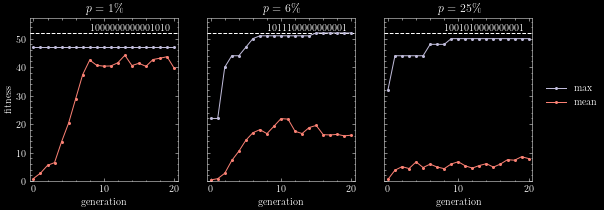

In [278]:
plt.style.use('dark_background')
fig, axes = plt.subplots(1, len(mutRates), figsize=(9,3), sharex=True, sharey=True)

linesBest = np.empty([len(axes)], dtype='object')
linesAve = np.empty([len(axes)], dtype='object')
bestLabels = np.empty([len(axes)], dtype='object')

for i in range(len(axes)):
    
    axes[i].set_xlabel('generation')
    axes[i].set_title(r'$p={:.0f}\%$'.format(100*mutRates[i]))
    
    fit_best = fitsBests[i]
    fit_ave = fitsAves[i]

    axes[i].set_xlim(-0.5, gMax+0.5)
    axes[i].set_ylim(0, 1.1*bestFit)
    axes[i].axhline(bestFit, ls='--')
    linesBest[i], = axes[i].plot(fit_best, '-oC2', ms=2, label='max')
    linesAve[i], = axes[i].plot(fit_ave, '-oC3', ms=2, label='mean')
    bestLabels[i] = axes[i].text(gMax/2.5, 53, "".join([str(d) for d in fittestHists[i,-1]]), fontsize=10)

axes[0].set_ylabel('fitness')
axes[2].legend(bbox_to_anchor=(1.5,0.65))

for g in range(gMax+1):
    for i in range(len(axes)):
        fit_best = fitsBests[i,:(g+1)]
        fit_ave = fitsAves[i,:(g+1)]
        linesBest[i].set_data((np.arange(len(fit_best)), fit_best))
        linesAve[i].set_data((np.arange(len(fit_ave)), fit_ave))
        bestLabels[i].set_text("".join([str(d) for d in fittestHists[i,g]]))
    
    plt.savefig('myAnim-' + str(g) + '.png', dpi=300)

plt.show()

In [106]:
def normalPDF(z):
    return np.exp(-z**2 / 2) / np.sqrt(2*np.pi)

In [147]:
def runKnap(p, runs):
    nPop = 50
    nElite = 5
    gMax = 20
    n = 16
    maxWeight = 50
    
    successes = 0
    for r in range(runs):
        weights = np.sort(np.random.randint(1, 31, size=n))
        values = np.sort(np.random.randint(1, 31, size=n))

        bestFit = 0
        bestDigs = np.zeros(n)
        for t in range(2**n):
            digs = np.array([int(d) for d in '{:b}'.format(t)])
            digs = np.array([*np.zeros(n-len(digs)), *digs], dtype='int')
            fit = fitnessKnap(digs)
            if fit > bestFit:
                bestFit = fit
                bestDigs = digs
        
        fittestHist, fitsBest, fitsAve = knapsack(n, nPop, nElite, gMax, p)

        if bestFit == fitsBest[-1]:
            successes += 1

    return successes

In [148]:
nruns = 250
logpList = np.zeros(nruns)
success = np.zeros(nruns)

for i in range(nruns):
    if i % 10 == 0:
        print('run', i)
    logp = -3*np.random.random()
    logpList[i] = logp
    success[i] = runKnap(10**logp, 1)

run 0
run 10
run 20
run 30
run 40
run 50
run 60
run 70
run 80
run 90
run 100
run 110
run 120
run 130
run 140
run 150
run 160
run 170
run 180
run 190
run 200
run 210
run 220
run 230
run 240


In [279]:
logpp = np.linspace(-3, 0, 100)
dns = np.zeros(len(logpp))
val = np.zeros(len(logpp))

sig = np.std(logpList) * nruns**(-1/5)

for j in range(nruns):
    gaussian = normalPDF((logpp-logpList[j]) / sig) / sig
    dns += gaussian
    val += success[j] * gaussian
    
eff = val / dns

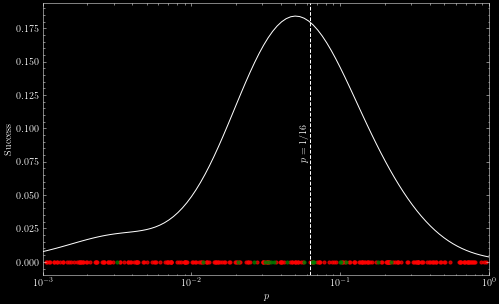

In [284]:
fig, ax = plt.subplots(1, 1, figsize=(8,5))

ax.scatter(10**logpList[success == 0], success[success == 0], s=10, c='r', alpha=0.75)
ax.scatter(10**logpList[success == 1], 1-success[success == 1], s=10, c='g', alpha=0.75)

ax.plot(10**logpp, eff, 'w', lw=1, alpha=alpha)
    
ax.axvline(1/16, ls='--', lw=1)
ax.set_xscale('log')
ax.set_xlabel('$p$')
ax.set_ylabel('Success')
ax.set_xlim(10**-3, 1)
ax.set_ylim(-0.01)

ax.text(1/16-0.01, 0.075, '$p=1/16$', rotation=90)

plt.savefig('knapsack_opt.png', dpi=300)
plt.show()

# 2D optimization

In [3]:
def binToDec(xbin):
    return int(''.join([str(i) for i in xbin]), 2) / 2**len(xbin)

In [4]:
def randChrome(n):
    return np.random.choice([0, 1], size=(2,n))

def fitness(c):
    x = binToDec(c[0])
    y = binToDec(c[1])
    
    return f(x, y)

def f(x, y):
    return 5*x*np.cos(6*np.pi*x) + 6*y*np.sin(5*np.pi*y)

In [5]:
def crossOver(p1, p2):
    xo = np.random.randint(1, len(p1[0]))
    
    c = p2.copy()
    c[:,:xo] = p1[:,:xo]
    
    return c

In [6]:
def mutate(c, mutRate):
    
    for i in range(2):
        for j in range(len(c[i])):
            if np.random.rand() < mutRate:
                c[i,j] = 1 - c[i,j]
    
    return c

In [7]:
def sortPop(pop):
    fits = np.array([fitness(c) for c in pop])
    order = np.argsort(fits)
    
    return pop[order], fits[order]

In [8]:
def binTourney(fits):
    i1, i2 = np.random.randint(len(fits), size=2)
    if fits[i1] < fits[i2]:
        return i1
    else:
        return i2

In [9]:
def GA(n, nPop, nElite, gMax, mutRate):

    popHist = np.zeros([gMax, nPop, 2])
    fitsBest = np.zeros(gMax)
    fitsAve = np.zeros(gMax)
    
    pop = np.array([randChrome(n) for i in range(nPop)])
    pop, fits = sortPop(pop)
    
    popHist[0] = [[binToDec(c[0]), binToDec(c[1])] for c in pop]
    fitsBest[0] = fits[0]
    fitsAve[0] = np.mean(fits)

    for g in range(gMax):

        popNext = np.zeros([nPop, 2, n], dtype='int')
        popNext[:nElite] = pop[:nElite]

        for i in range(nElite, nPop):
            p1 = binTourney(fits)
            p2 = binTourney(fits)

            child = crossOver(pop[p1], pop[p2])
            child = mutate(child, mutRate)

            popNext[i] = child

        pop = popNext.copy()
        pop, fits = sortPop(pop)
        
        popHist[g] = [[binToDec(c[0]), binToDec(c[1])] for c in pop]
        fitsBest[g] = fits[0]
        fitsAve[g] = np.mean(fits)
        
    return popHist, fitsBest, fitsAve

<IPython.core.display.Javascript object>


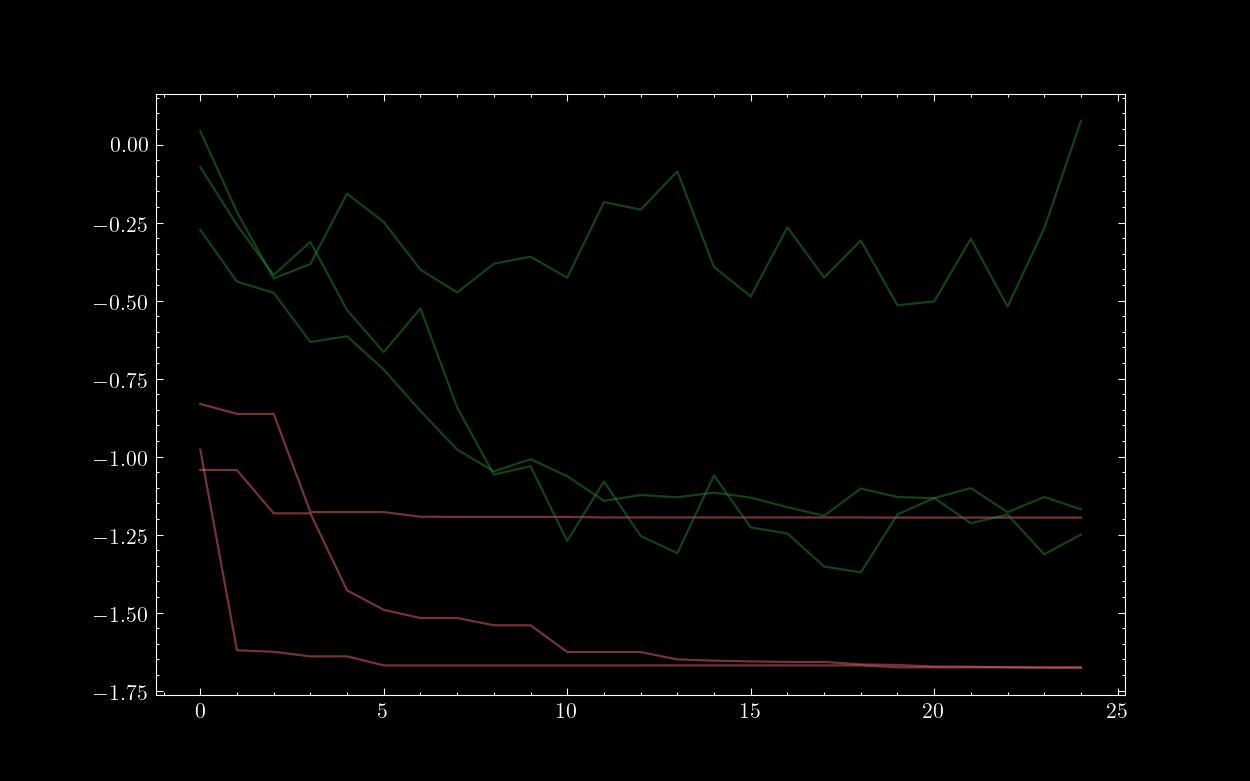

In [24]:
n = 10
nPop = 25
nElite = 2
gMax = 25

mutRates = [0.01, 0.05, 0.2]

popHists = np.zeros([len(mutRates), gMax, nPop, 2])
fitsBests = np.zeros([len(mutRates), gMax])
fitsAves = np.zeros([len(mutRates), gMax])

for i in range(len(mutRates)):
    
    popHist, fitsBest, fitsAve = GA(n, nPop, nElite, gMax, mutRates[i])
    
    popHists[i] = popHist
    fitsBests[i] = fitsBest
    fitsAves[i] = fitsAve

plt.subplots(1, 1, figsize=(8,5))
plt.plot(fitsBests.T, 'C1', alpha=0.5)
plt.plot(fitsAves.T, 'C2', alpha=0.5)
# plt.ylim(0, 2*n+1)
plt.show()

<IPython.core.display.Javascript object>


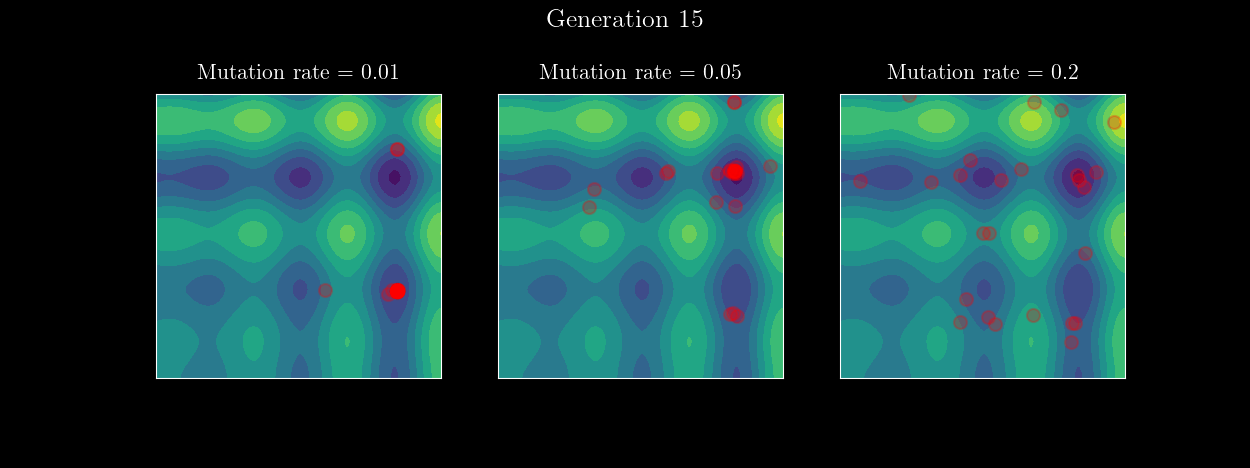

In [29]:
def animate(g):
    for i in range(len(mutRates)):
        ax = axes[i]
        x_data, y_data = popHists[i,g,:,0], popHists[i,g,:,1]
        scatters[i].set_data((x_data, y_data))
        fig.suptitle('Generation {: >3d}'.format(g+1))

xx, yy = np.meshgrid(np.linspace(0,1,101), np.linspace(0,1,101))
x_data, y_data = popHist[0,:,0], popHist[0,:,1]

fig, axes = plt.subplots(1, len(mutRates), figsize=(8,3), sharex=True, sharey=True)
fig.suptitle('Generation 1')
scatters = np.empty(len(mutRates), dtype='object')
for i in range(len(mutRates)):
    ax = axes[i]
    mutRate = mutRates[i]
    x_data, y_data = popHists[i,0,:,0], popHists[i,0,:,1]
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect(1)
    ax.set_title("Mutation rate = " + str(mutRate), size=10)
    ax.contourf(xx, yy, f(xx, yy), 10, cmap='viridis')
    scatters[i], = ax.plot(x_data, y_data, 'ro', alpha=0.25)

anim = FuncAnimation(fig, animate, frames=gMax, interval=500, repeat_delay=2000)
plt.show()